In [2]:
import jax
import jax.numpy as jnp
# Set CPU as default device
jax.config.update("jax_platform_name", "cpu")




X_train1 = jax.random.normal(jax.random.PRNGKey(0), (20,)) - 5
X_train2 = jax.random.normal(jax.random.PRNGKey(1), (20,)) + 3
X_train = jax.numpy.concatenate([X_train1, X_train2])[:, None]

y_train = jnp.sin(X_train)*X_train + 0.1*jax.random.normal(jax.random.PRNGKey(2), (40, 1))


In [212]:
import flax.linen as nn
import jax.scipy.stats as stats


class NN(nn.Module):
    @nn.compact
    def __call__(self, x):
        #x = jnp.hstack([jnp.sin(x*jnp.arange(1,5))/jnp.arange(1,5), jnp.cos(x*jnp.arange(1,5))/jnp.arange(1,5)])
        x = x * jnp.ones((10,))
        x = nn.Dense(features=50)(x)
        x = nn.tanh(x)
        x = nn.Dense(features=1)(x)
        return x


model = NN()


def logprior_fn(params):
    """Compute the value of the log-prior density function."""
    leaves, _ = jax.tree_util.tree_flatten(params)
    flat_params = jnp.concatenate([jnp.ravel(a) for a in leaves])
    return jnp.sum(stats.norm.logpdf(flat_params, scale=1.))


def loglikelihood_fn(params, data):
    """Categorical log-likelihood"""
    X, y = data
    y_pred = model.apply(params, X)
    return jax.scipy.stats.norm.logpdf(y, y_pred, scale=0.1).sum()

In [265]:
import blackjax
from functools import partial


num_particles = 100
rng_key = jax.random.PRNGKey(0)


rng_key, batch_key = jax.random.split(rng_key)

init_keys = jax.random.split(rng_key, num_particles)
params = jax.vmap(model.init)(init_keys, jnp.ones((num_particles,) + (X_train.shape[-1],)))

In [266]:

def logdensity_fn(params):
    return loglikelihood_fn(params, (X_train, y_train)) + logprior_fn(params)

In [267]:
from jax.flatten_util import ravel_pytree

In [268]:
param_single = jax.tree_map(lambda x: x[0], params)
num_params =ravel_pytree(param_single)[0].shape[0]
print(num_params)
inverse_mass_matrix = jnp.ones((num_params,))

hmc_parameters = {
    "step_size":5e-4,
    "inverse_mass_matrix":inverse_mass_matrix,
    "num_integration_steps":10,
    "logdensity_fn":logdensity_fn,
    
}

601


In [269]:
kernel = blackjax.hmc.build_kernel()

In [270]:
states = jax.vmap(blackjax.hmc.init, in_axes=(0,None))(params, logdensity_fn)

In [271]:
from functools import partial


@jax.jit
def mcmc_step(rng_key, states):
    keys = jax.random.split(rng_key, (num_particles,))
    _kernel = partial(kernel, **hmc_parameters)
    states, info = jax.vmap(_kernel)(keys, states)
    return states,info

In [272]:
from fastprogress.fastprogress import progress_bar

num_warmup = 10000

accuracies = []
steps = []
pb = progress_bar(range(num_warmup))
for step in pb:
    rng_key, batch_key, sample_key = jax.random.split(rng_key,3)
    states,info = mcmc_step(sample_key, states)
    
    if step % 50 == 0:
        accuracy = states.logdensity.mean()
        accept = info.acceptance_rate.mean()
        accuracies.append(accuracy)
        steps.append(step)
        pb.comment = f"| error: {accuracy: .1f}| accept: {accept: .1f}"

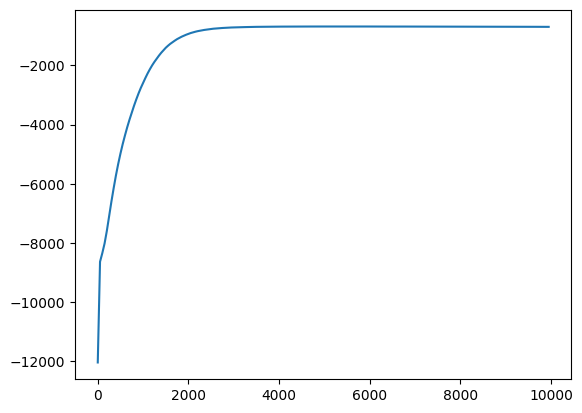

In [273]:
import matplotlib.pyplot as plt
plt.plot(steps, accuracies)

In [274]:
X_test = jnp.linspace(-10, 10, 500)

y_pred = jax.vmap(model.apply, in_axes=(0, None))(states.position, X_test[:, None])

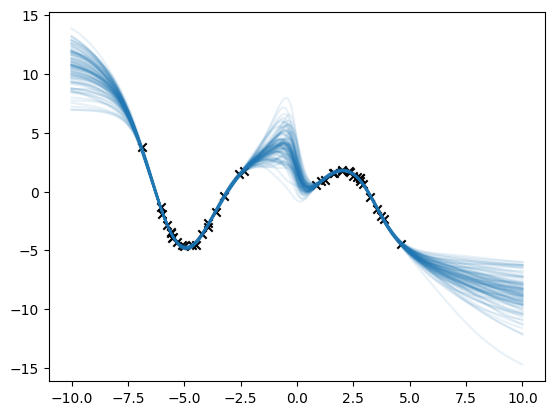

In [275]:
_ = plt.plot(X_test, y_pred[...,0].T, color="C0", alpha=0.1)
plt.scatter(X_train, y_train, color="black", marker="x")

In [338]:
import optax 

optimizer = optax.adam(1e-5)
param = model.init(jax.random.PRNGKey(0), X_train)
opt_state = optimizer.init(param)

def loss_fn(params):
    return -logdensity_fn(params)

@jax.jit
def update(params, opt_state):
    loss, grad = jax.value_and_grad(loss_fn)(params)
    updates, opt_state = optimizer.update(grad, opt_state)
    new_params = optax.apply_updates(params, updates)
    return new_params, opt_state, loss


In [339]:
from fastprogress.fastprogress import progress_bar

num_epochs = 500_000

losses = []
pb = progress_bar(range(num_epochs))
for epoch in pb:
    param, opt_state, loss = update(param, opt_state)
    losses.append(loss)
    pb.comment = f"| loss: {loss.mean(): .1f}"


In [357]:
from fastprogress.fastprogress import progress_bar

num_epochs = 500_000

losses = []
pb = progress_bar(range(num_epochs))
for epoch in pb:
    param, opt_state, loss = update(param, opt_state)
    losses.append(loss)
    pb.comment = f"| loss: {loss.mean(): .1f}"


In [360]:
from fastprogress.fastprogress import progress_bar

num_epochs = 500_000

losses = []
pb = progress_bar(range(num_epochs))
for epoch in pb:
    param, opt_state, loss = update(param, opt_state)
    losses.append(loss)
    pb.comment = f"| loss: {loss.mean(): .1f}"


In [406]:
X_test = jnp.linspace(-10, 10, 500)

y_pred = model.apply(param, X_test[:, None])

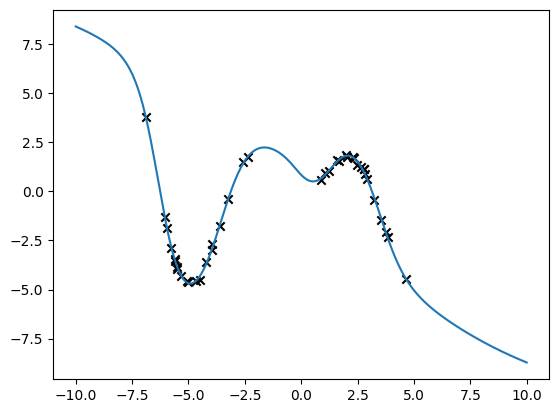

In [407]:
_ = plt.plot(X_test, y_pred[...,0].T, color="C0")
plt.scatter(X_train, y_train, color="black", marker="x")

In [408]:
flat_param, unflatten = ravel_pytree(param)
H = jax.hessian(lambda x: loss_fn(unflatten(x)))(flat_param)

In [422]:
import numpy as np
H = np.array(H, dtype=np.float64)

In [432]:
C = np.linalg.inv(H)

In [447]:
def sample_params(key):
    return jax.random.multivariate_normal(key, flat_param,C)

In [448]:
params = jax.vmap(sample_params)(jax.random.split(jax.random.PRNGKey(0), 100))
params = jax.vmap(unflatten)(params)

In [449]:
X_test = jnp.linspace(-10, 10, 500)

y_pred = jax.vmap(model.apply, in_axes=(0, None))(params, X_test[:, None])

In [450]:
y_pred

Array([[[-17.487461 ],
        [-17.488335 ],
        [-17.489113 ],
        ...,
        [ 14.034819 ],
        [ 14.065732 ],
        [ 14.096274 ]],

       [[-14.15957  ],
        [-14.163288 ],
        [-14.167085 ],
        ...,
        [ 10.835436 ],
        [ 10.846857 ],
        [ 10.858153 ]],

       [[ -8.1435585],
        [ -8.136836 ],
        [ -8.1300745],
        ...,
        [  9.34788  ],
        [  9.361142 ],
        [  9.37443  ]],

       ...,

       [[-11.911527 ],
        [-11.921802 ],
        [-11.932077 ],
        ...,
        [  3.6966949],
        [  3.7501483],
        [  3.8033633]],

       [[-11.560396 ],
        [-11.586269 ],
        [-11.612273 ],
        ...,
        [  1.2512133],
        [  1.268361 ],
        [  1.2853158]],

       [[-10.405506 ],
        [-10.398346 ],
        [-10.391183 ],
        ...,
        [  8.3376665],
        [  8.344234 ],
        [  8.350617 ]]], dtype=float32)

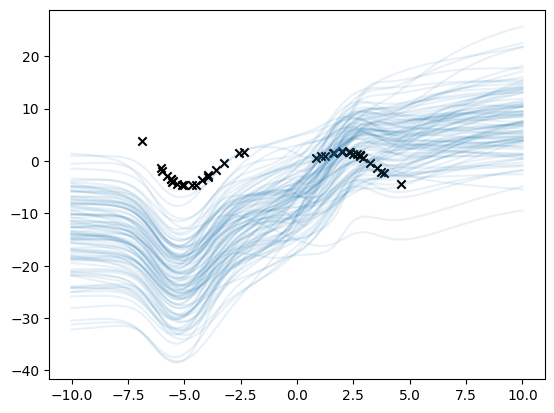

In [451]:
_ = plt.plot(X_test, y_pred[...,0].T, color="C0", alpha=0.1)
plt.scatter(X_train, y_train, color="black", marker="x")

In [520]:
# enable 64-bit floating point precision

jax.config.update("jax_enable_x64", True)

In [550]:
J1 = jax.jacobian(lambda param: model.apply(unflatten(param), X_test[0]))(flat_param)

In [555]:
def ntk(x,y):
    J1 = jax.jacobian(lambda x: model.apply(param, x))(x)
    J2 = jax.jacobian(lambda x: model.apply(param, x))(y)
    return jnp.dot(J1,J2.T)

K = jax.vmap(jax.vmap(ntk, in_axes=(0,None)), in_axes=(None,0))(X_test, X_test) + 5e-5*jnp.eye(500)

In [556]:
def lla(x, y):
    J1 = jax.jacobian(lambda param: model.apply(unflatten(param), x))(flat_param)
    J2 = jax.jacobian(lambda param: model.apply(unflatten(param), y))(flat_param)
    return J1 @ C @ J2.T
    

In [533]:
def sample_gp(key, X_test, num_samples):
    K = jax.vmap(jax.vmap(ntk, in_axes=(0,None)), in_axes=(None,0))(X_test, X_test) + 5e-5*jnp.eye(X_test.shape[0])
    f_map = jax.vmap(lambda x: model.apply(param, x))(X_test)[...,0]
    eps = jax.random.multivariate_normal(key, jnp.zeros_like(f_map), K, shape=(num_samples,))
    return f_map + eps

In [534]:
y_preds = sample_gp(jax.random.PRNGKey(0), X_test, 100)

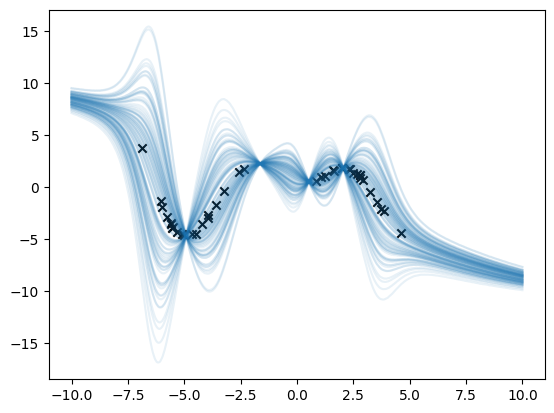

In [538]:
_ = plt.plot(X_test, y_preds.T, color="C0", alpha=0.1)
plt.scatter(X_train, y_train, color="black", marker="x")

In [565]:
std.shape

(500, 500)

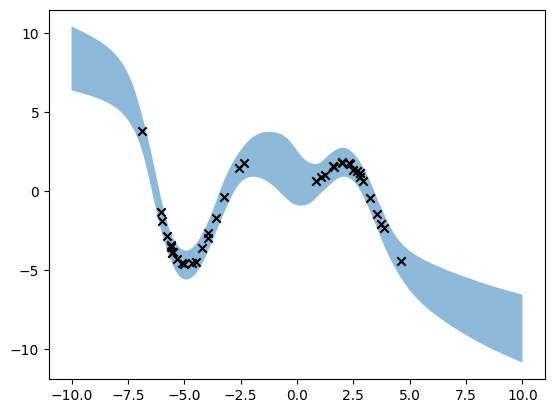

In [568]:
var = jax.vmap(lla)(X_test, X_test)[:,0,0]
std = jnp.sqrt(std)
mean = jax.vmap(lambda x: model.apply(param, x))(X_test)[...,0]
plt.fill_between(X_test, mean - 2*std, mean + 2*std, alpha=0.5)
plt.scatter(X_train, y_train, color="black", marker="x")